In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"asadejaz12","key":"5b03896240ef9b7cfc3f6cdff2d5a5a6"}'}

In [2]:
#create kaggle directory
!mkdir ~/.kaggle
#copy kaggle.json file
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
!kaggle datasets download -d 'omkargurav/face-mask-dataset'

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:09<00:00, 17.4MB/s]



In [4]:
!unzip face-mask-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: data/with_mask/with_mask_3297.jpg  
  inflating: data/with_mask/with_mask_3298.jpg  
  inflating: data/with_mask/with_mask_3299.jpg  
  inflating: data/with_mask/with_mask_33.jpg  
  inflating: data/with_mask/with_mask_330.jpg  
  inflating: data/with_mask/with_mask_3300.jpg  
  inflating: data/with_mask/with_mask_3301.jpg  
  inflating: data/with_mask/with_mask_3302.jpg  
  inflating: data/with_mask/with_mask_3303.jpg  
  inflating: data/with_mask/with_mask_3304.jpg  
  inflating: data/with_mask/with_mask_3305.jpg  
  inflating: data/with_mask/with_mask_3306.jpg  
  inflating: data/with_mask/with_mask_3307.jpg  
  inflating: data/with_mask/with_mask_3308.jpg  
  inflating: data/with_mask/with_mask_3309.jpg  
  inflating: data/with_mask/with_mask_331.jpg  
  inflating: data/with_mask/with_mask_3310.jpg  
  inflating: data/with_mask/with_mask_3311.jpg  
  inflating: data/with_mask/with_mask_3312.jpg  
  inflating: data/with

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D,Input, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score
BATCH_SIZE = 32
IMG_SIZE = (160, 160)
SEED = 42

In [6]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/data',
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    )
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/data',
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

Found 7553 files belonging to 2 classes.
Using 6043 files for training.
Found 7553 files belonging to 2 classes.
Using 1510 files for validation.


In [7]:
#Normalize
def process(image,label):
    image = tf.cast(image/255, tf.float32)
    return image, label

train_ds= train_ds.map(process)
validation_ds = validation_ds.map(process)

In [8]:
#create cnn model
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

cnn = Sequential()

cnn.add(Input(shape=(256, 256, 3)))
cnn.add(data_augmentation)

cnn.add(Conv2D(32, kernel_size =(3,3), padding= 'valid', activation='relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

cnn.add(Conv2D(64, kernel_size =(3,3), padding= 'valid', activation='relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

cnn.add(Conv2D(128, kernel_size =(3,3), padding= 'valid', activation='relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

cnn.add(GlobalAveragePooling2D())
cnn.add(Dropout(0.4))
cnn.add(Dense(128, activation='relu'))
cnn.add(Dropout(0.3))
cnn.add(Dense(1, activation='sigmoid'))

In [9]:
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics= ['accuracy'])
callback = EarlyStopping(
    monitor="val_loss",
    patience=3,
    verbose=1,
    mode="auto",
    restore_best_weights=True
    )

In [10]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
history = cnn.fit(
    train_ds,
    epochs=10,
    validation_data=validation_ds,
    verbose=1,
    callbacks=[callback]
)

Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step - accuracy: 0.7437 - loss: 0.5360 - val_accuracy: 0.5152 - val_loss: 0.7266
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.7683 - loss: 0.4954 - val_accuracy: 0.5099 - val_loss: 1.6332
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.7913 - loss: 0.4524 - val_accuracy: 0.6722 - val_loss: 0.5647
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.8350 - loss: 0.3896 - val_accuracy: 0.8026 - val_loss: 0.4442
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.8736 - loss: 0.3125 - val_accuracy: 0.5391 - val_loss: 2.2859
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.8939 - loss: 0.2703 - val_accuracy: 0.7205 - val_loss: 0.6270
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.9138 - loss: 0.2236 - val_accuracy: 0.8722 - val_loss: 0.3552
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.9201 - loss: 0.2087 - 

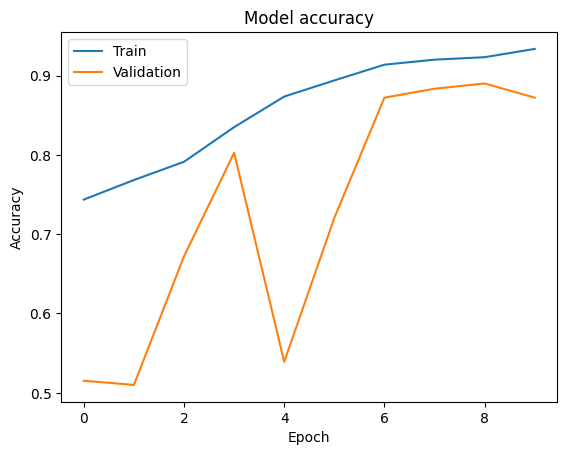

In [13]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

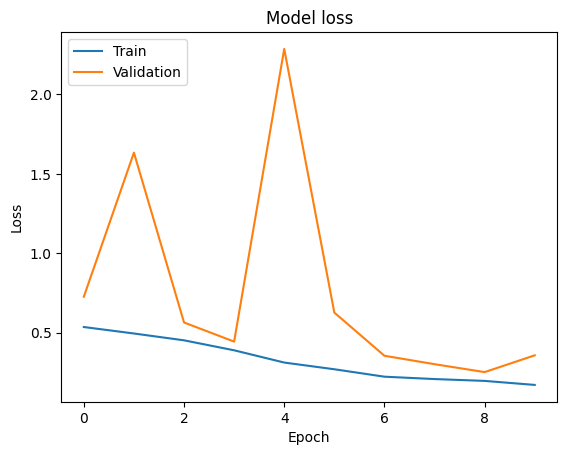

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
#

In [15]:
cnn.save('Face-mask-detection.keras')